### Main notebook

Run all scripts and show results from here!

In [1]:
import pandas as pd

dataset_csv = pd.read_csv('dataset/rrdataset_new_split.csv')

In [ ]:
from modules.data import RRDataset
from torchvision import transforms

CROP = 224
NORM = transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])

# More informative random crops in training
tf_train = transforms.Compose([
    transforms.Resize(CROP),
    transforms.RandomCrop(CROP),          
    transforms.RandomHorizontalFlip(),   
    transforms.ToTensor(),
    NORM,
])

# Deterministic in evaluation
tf_eval = transforms.Compose([
    transforms.Resize(CROP),
    transforms.CenterCrop(CROP),
    transforms.ToTensor(),
    NORM,
])

train_set = RRDataset(dataset_csv, 'train', apply_transform=tf_train)
val_set   = RRDataset(dataset_csv, 'val',   apply_transform=tf_eval)
test_set  = RRDataset(dataset_csv, 'test',  apply_transform=tf_eval)

In [3]:
from torch.utils.data import DataLoader
from modules.data import collate_fn

train_loader = DataLoader(
    train_set,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    collate_fn=collate_fn,
)

test_loader = DataLoader(
    test_set,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    collate_fn=collate_fn,
)

val_loader = DataLoader(
    val_set,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    collate_fn=collate_fn,
)

In [4]:
data_iter = iter(train_loader)
images, labels, tf_labels, tf_names, contexts = next(data_iter)

print(f"Image Batches Shape: {images.shape}")   # [Batch, Channel, H, W]
print(f"Labels Batch Shape: {labels.shape}")     # [Batch]
print(f"First label value example: {labels[0].item()}")
print(f"First transform name: {tf_names[0]}")

Image Batches Shape: torch.Size([32, 3, 224, 224])
Labels Batch Shape: torch.Size([32])
First label value example: 0
First transform name: original


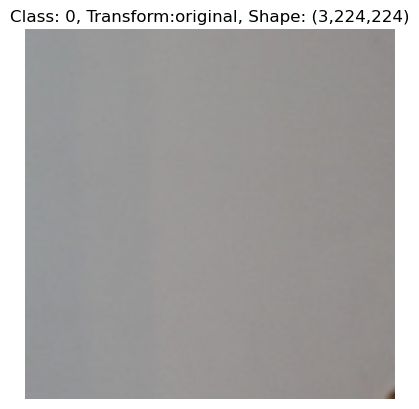

In [5]:
from modules.utils import show_sample

show_sample(images[0], labels[0].item(), tf_names[0])

In [6]:
import torch
import torch.nn as nn
from modules.network import UnimodalNet
from modules.train import train_model, evaluate

device = "cuda" if torch.cuda.is_available() else "cpu"

criterion = nn.CrossEntropyLoss()

# --- baseline unimodal real/fake ---
m1 = UnimodalNet("realfake").to(device)
opt1 = torch.optim.Adam([
    {"params": m1.backbone.layer4.parameters(), "lr": 1e-4},
    {"params": m1.head.parameters(),            "lr": 1e-3},
])

m1, h1 = train_model(m1, train_loader, val_loader, opt1, criterion, device, epochs=10, save_path='checkpoints/unimodal_realfake.pt')

/usr/lib/python3/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Epochs:   0%|          | 0/10 [00:13<?, ?it/s]


ValueError: Caught ValueError in DataLoader worker process 1.
Original Traceback (most recent call last):
  File "/home/rems/.local/lib/python3.12/site-packages/torch/utils/data/_utils/worker.py", line 374, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/home/rems/.local/lib/python3.12/site-packages/torch/utils/data/_utils/fetch.py", line 54, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "/home/rems/code/post_processed_ai_gen_detection/modules/data.py", line 44, in __getitem__
    img = self.transform(img)
          ^^^^^^^^^^^^^^^^^^^
  File "/home/rems/.local/lib/python3.12/site-packages/torchvision/transforms/transforms.py", line 95, in __call__
    img = t(img)
          ^^^^^^
  File "/home/rems/.local/lib/python3.12/site-packages/torch/nn/modules/module.py", line 1778, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
      

In [ ]:
print(evaluate(m1, test_loader, device))